# Network Analysis — AI Coding Assistant Trust & Distrust
**COSC 3047 Assignment 2**

This notebook constructs and analyses a directed user interaction network from social media comments about AI coding assistants.

**Network definition:**
- **Nodes** — unique users (commenters)
- **Edges** — directed reply relationships (user A replied to user B)
- **Edge weight** — number of times A replied to B

**Analyses performed:**
1. Graph construction from reply edges across all data sources
2. Basic network statistics (density, components, degree distribution)
3. Centrality analysis (PageRank, in-degree, betweenness) — identifying influential users
4. Community detection (Louvain) — finding discussion clusters
5. Cross-analysis — linking network position to sentiment and topic labels

**Data sources:**
- ✅ YouTube reply edges (`data/processed/youtube/reply_edges.json`)
- ⬜ Hacker News reply edges (`data/processed/hackernews/hn_reply_edges.json`) — plug in when available
- ⬜ GitHub reply edges (`data/processed/github/gh_reply_edges.json`) — plug in when available

**Input:** `data/processed/youtube/reply_edges.json`, `data/processed/nlp/comments_with_topics.csv`  
**Output:** `data/processed/network/`

## 1. Setup & Imports

In [3]:
import json
import logging
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from community import community_louvain

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

print("Imports done.")

Imports done.


In [7]:
# Find project root by looking for .git folder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".git").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

OUTPUT_DIR    = PROJECT_ROOT / "data/processed/network"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

YT_EDGES_PATH = PROJECT_ROOT / "data/processed/youtube/reply_edges.json"
HN_EDGES_PATH = PROJECT_ROOT / "data/processed/hackernews/hn_reply_edges.json"
GH_EDGES_PATH = PROJECT_ROOT / "data/processed/github/gh_reply_edges.json"
NLP_PATH      = PROJECT_ROOT / "data/processed/nlp/comments_with_topics.csv"

print(f"YouTube edges: {YT_EDGES_PATH.exists()}")
print(f"NLP data:      {NLP_PATH.exists()}")

Project root: /Users/gayathwethmin/Downloads/social_media_2
YouTube edges: True
NLP data:      True


## 2. Load & Combine Edge Data

Reply edges from all available sources are loaded and combined into a single edge list.
Each edge has a `source` (replier), `target` (original commenter), `weight` (reply count), and `platform` label.
When HN and GitHub data becomes available, add their edge files to the loader below — no other changes needed.

In [8]:
print(YT_EDGES_PATH)
print(YT_EDGES_PATH.exists())

# Check what's in it
with open(YT_EDGES_PATH) as f:
    data = json.load(f)
print(type(data))
print(len(data))
if len(data) > 0:
    print(data[0])

/Users/gayathwethmin/Downloads/social_media_2/data/processed/youtube/reply_edges.json
True
<class 'list'>
5211
{'source': '', 'target': '@hudsonkanizawa', 'videoId': '8hNcRChDrNk', 'weight': 1}


In [9]:
def load_edges(path: Path, platform: str) -> pd.DataFrame:
    """Load reply edges from a JSON file and tag with platform label."""
    if not path.exists():
        log.warning(f"{platform} edges not found at {path} — skipping.")
        return pd.DataFrame()
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df["platform"] = platform
    log.info(f"Loaded {len(df):,} {platform} edges")
    return df

# Load all available sources
yt_edges = load_edges(YT_EDGES_PATH, "youtube")
# hn_edges = load_edges(HN_EDGES_PATH, "hackernews")   # empty until teammate adds data
# gh_edges = load_edges(GH_EDGES_PATH, "github")        # empty until teammate adds data

# Combine — filter to non-empty DataFrames only
available = [df for df in [yt_edges] if not df.empty]
edges_df = pd.concat(available, ignore_index=True)

# Standardise columns — ensure source, target, weight exist
if "weight" not in edges_df.columns:
    edges_df["weight"] = 1

# Aggregate duplicate edges (same source→target pair across videos)
edges_df = (
    edges_df
    .groupby(["source", "target", "platform"])
    .agg(weight=("weight", "sum"))
    .reset_index()
)

# Remove self-loops
edges_df = edges_df[edges_df["source"] != edges_df["target"]]

print(f"Total edges:        {len(edges_df):,}")
print(f"Unique sources:     {edges_df['source'].nunique():,}")
print(f"Unique targets:     {edges_df['target'].nunique():,}")
print(f"Platforms:          {edges_df['platform'].value_counts().to_dict()}")
edges_df.head()

18:14:11 [INFO] Loaded 5,211 youtube edges


Total edges:        4,745
Unique sources:     3,220
Unique targets:     2,556
Platforms:          {'youtube': 4745}


,source,target,platform,weight
0,,@hudsonkanizawa,youtube,1
1,@-Engineering01-,@SomeRandomUserOFYT,youtube,1
2,@-Engineering01-,@abyrvalg809,youtube,1
3,@-Engineering01-,@attoumak,youtube,1
4,@-Engineering01-,@avidlearner8117,youtube,1


## 3. Load NLP Data

Sentiment scores and topic labels from the NLP notebook are loaded here.
These are joined to network nodes to enable cross-analysis — linking a user's network position to what they say and how they say it.

In [10]:
nlp_df = pd.read_csv(NLP_PATH)

# Build user-level sentiment profile
# For each user: average compound score, dominant sentiment, dominant topic
user_profiles = (
    nlp_df.groupby("commentAuthor")
    .agg(
        avg_sentiment=("sentiment_compound", "mean"),
        comment_count=("commentText", "count"),
        dominant_topic=("topic_label", lambda x: x.value_counts().index[0] if len(x) > 0 else "unknown"),
        total_likes=("commentLikeCount", "sum")
    )
    .reset_index()
)

# Assign sentiment label
user_profiles["sentiment_label"] = user_profiles["avg_sentiment"].apply(
    lambda x: "positive" if x >= 0.05 else "negative" if x <= -0.05 else "neutral"
)

print(f"User profiles built: {len(user_profiles):,} unique users")
print(f"Sentiment distribution:")
print(user_profiles["sentiment_label"].value_counts())
user_profiles.head()

User profiles built: 19,588 unique users
Sentiment distribution:
sentiment_label
positive    11301
neutral      4922
negative     3365
Name: count, dtype: int64


,commentAuthor,avg_sentiment,comment_count,dominant_topic,total_likes,sentiment_label
0,@---David---,0.826800,1,productivity,1,positive
1,@-AkhilTej-,0.804700,2,productivity,0,positive
2,@-Engineering01-,-0.028377,13,productivity,7,neutral
3,@-Kunalarya,0.000000,1,productivity,3,neutral
4,@-R-.,0.245833,3,productivity,8,positive


## 4. Graph Construction

A directed weighted graph is constructed from the combined edge list.
- **Directed** — because a reply from A to B does not imply B replied to A
- **Weighted** — edge weight represents the number of times A replied to B, capturing interaction strength

Node attributes (sentiment, topic, comment count) from the NLP stage are attached to each node.

In [11]:
# Build directed weighted graph
G = nx.DiGraph()

# Add weighted edges
for _, row in edges_df.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["weight"],
        platform=row["platform"]
    )

# Attach NLP attributes to nodes
user_dict = user_profiles.set_index("commentAuthor").to_dict(orient="index")
for node in G.nodes():
    if node in user_dict:
        for attr, val in user_dict[node].items():
            G.nodes[node][attr] = val
    else:
        G.nodes[node]["avg_sentiment"] = 0.0
        G.nodes[node]["sentiment_label"] = "unknown"
        G.nodes[node]["dominant_topic"] = "unknown"
        G.nodes[node]["comment_count"] = 0
        G.nodes[node]["total_likes"] = 0

print(f"Graph constructed:")
print(f"  Nodes (users):    {G.number_of_nodes():,}")
print(f"  Edges (replies):  {G.number_of_edges():,}")
print(f"  Density:          {nx.density(G):.6f}")
print(f"  Is DAG:           {nx.is_directed_acyclic_graph(G)}")

Graph constructed:
  Nodes (users):    5,624
  Edges (replies):  4,745
  Density:          0.000150
  Is DAG:           False


## 5. Basic Network Statistics

Basic structural properties of the network are examined before centrality analysis.
Degree distribution reveals whether the network follows a power law (few highly connected nodes, many peripheral ones) — typical of social networks and indicative of influential users.

In [12]:
# Connected components (on undirected version)
G_undirected = G.to_undirected()
components = list(nx.connected_components(G_undirected))
largest_cc = max(components, key=len)

print(f"Connected components:       {len(components):,}")
print(f"Largest component size:     {len(largest_cc):,} nodes ({len(largest_cc)/G.number_of_nodes()*100:.1f}% of graph)")
print(f"Isolated nodes:             {sum(1 for c in components if len(c) == 1):,}")
print()

# Degree stats
in_degrees  = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree  — max: {max(in_degrees.values())}, mean: {np.mean(list(in_degrees.values())):.2f}")
print(f"Out-degree — max: {max(out_degrees.values())}, mean: {np.mean(list(out_degrees.values())):.2f}")
print()

# Top 5 most replied-to users (high in-degree = influential targets)
top_targets = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 most replied-to users:")
for user, deg in top_targets:
    sentiment = G.nodes[user].get("sentiment_label", "unknown")
    topic = G.nodes[user].get("dominant_topic", "unknown")
    print(f"  {user[:40]:40s} in-degree: {deg:4d} | sentiment: {sentiment} | topic: {topic}")

Connected components:       959
Largest component size:     1,230 nodes (21.9% of graph)
Isolated nodes:             0

In-degree  — max: 71, mean: 0.84
Out-degree — max: 162, mean: 0.84

Top 5 most replied-to users:
  @JeffSu                                  in-degree:   71 | sentiment: positive | topic: productivity
  @devforgehq                              in-degree:   67 | sentiment: positive | topic: productivity
  @jamesp9304                              in-degree:   50 | sentiment: negative | topic: productivity
  @Fireship                                in-degree:   49 | sentiment: positive | topic: productivity
  @_Digital_Dreams_                        in-degree:   30 | sentiment: neutral | topic: reliability


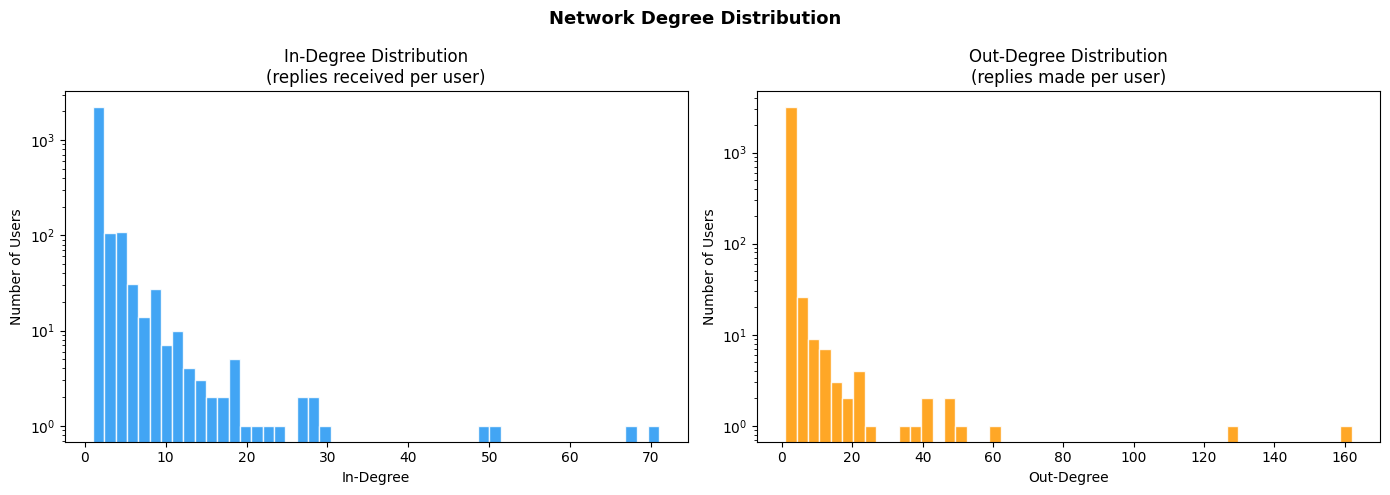

Saved degree_distribution.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Network Degree Distribution", fontsize=13, fontweight="bold")

# In-degree distribution
in_deg_vals = [d for _, d in G.in_degree() if d > 0]
axes[0].hist(in_deg_vals, bins=50, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].set_title("In-Degree Distribution\n(replies received per user)")
axes[0].set_xlabel("In-Degree")
axes[0].set_ylabel("Number of Users")
axes[0].set_yscale("log")

# Out-degree distribution
out_deg_vals = [d for _, d in G.out_degree() if d > 0]
axes[1].hist(out_deg_vals, bins=50, color="#FF9800", edgecolor="white", alpha=0.85)
axes[1].set_title("Out-Degree Distribution\n(replies made per user)")
axes[1].set_xlabel("Out-Degree")
axes[1].set_ylabel("Number of Users")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved degree_distribution.png")

## 6. Centrality Analysis

Three centrality measures are computed to identify influential users:

- **PageRank** — measures overall influence accounting for the quality of connections. A user with high PageRank is replied to by other highly-connected users. Chosen because it captures indirect influence, not just raw reply count.
- **In-degree centrality** — proportion of users who directly reply to this user. Simple but effective measure of who attracts the most engagement.
- **Betweenness centrality** — how often a user appears on the shortest path between two other users. High betweenness users act as bridges between communities.

Cross-referencing these measures with sentiment and topic labels directly answers the research question: *do influential users shape trust or distrust?*

In [14]:
log.info("Computing PageRank...")
pagerank = nx.pagerank(G, weight="weight", alpha=0.85)

log.info("Computing in-degree centrality...")
in_degree_centrality = nx.in_degree_centrality(G)

log.info("Computing betweenness centrality (on largest component)...")
# Betweenness on full graph is expensive — use largest component
G_lcc = G.subgraph(largest_cc).copy()
betweenness = nx.betweenness_centrality(G_lcc, weight="weight", normalized=True)

# Build centrality DataFrame
centrality_df = pd.DataFrame({
    "user": list(pagerank.keys()),
    "pagerank": list(pagerank.values()),
    "in_degree_centrality": [in_degree_centrality.get(u, 0) for u in pagerank.keys()],
    "betweenness": [betweenness.get(u, 0) for u in pagerank.keys()],
    "in_degree": [in_degrees.get(u, 0) for u in pagerank.keys()],
    "out_degree": [out_degrees.get(u, 0) for u in pagerank.keys()],
})

# Attach NLP attributes
centrality_df["sentiment_label"] = centrality_df["user"].map(
    lambda u: G.nodes[u].get("sentiment_label", "unknown")
)
centrality_df["dominant_topic"] = centrality_df["user"].map(
    lambda u: G.nodes[u].get("dominant_topic", "unknown")
)
centrality_df["avg_sentiment"] = centrality_df["user"].map(
    lambda u: G.nodes[u].get("avg_sentiment", 0.0)
)
centrality_df["total_likes"] = centrality_df["user"].map(
    lambda u: G.nodes[u].get("total_likes", 0)
)

centrality_df = centrality_df.sort_values("pagerank", ascending=False).reset_index(drop=True)

# Save
centrality_df.to_csv(OUTPUT_DIR / "centrality_scores.csv", index=False)

print("Top 15 most influential users (by PageRank):")
print(centrality_df[["user", "pagerank", "in_degree", "sentiment_label", "dominant_topic"]].head(15).to_string(index=False))

18:17:35 [INFO] Computing PageRank...
18:17:35 [INFO] Computing in-degree centrality...
18:17:35 [INFO] Computing betweenness centrality (on largest component)...


Top 15 most influential users (by PageRank):
                     user  pagerank  in_degree sentiment_label   dominant_topic
                  @JeffSu  0.007105         71        positive     productivity
              @devforgehq  0.006769         67        positive     productivity
              @jamesp9304  0.004960         50        negative     productivity
                @Fireship  0.004846         49        positive     productivity
               @saumay-z1  0.002938         28         neutral     productivity
        @_Digital_Dreams_  0.002888         30         neutral      reliability
              @Developete  0.002843         27        positive     productivity
           @AuroraMarinii  0.002699         27        negative     productivity
         @EhteshamShahzad  0.002603         28         neutral     productivity
          @dougsholly9323  0.002545         22        negative     productivity
          @taylorgledhill  0.002415         24         neutral      reliabi

### Centrality Visualisations

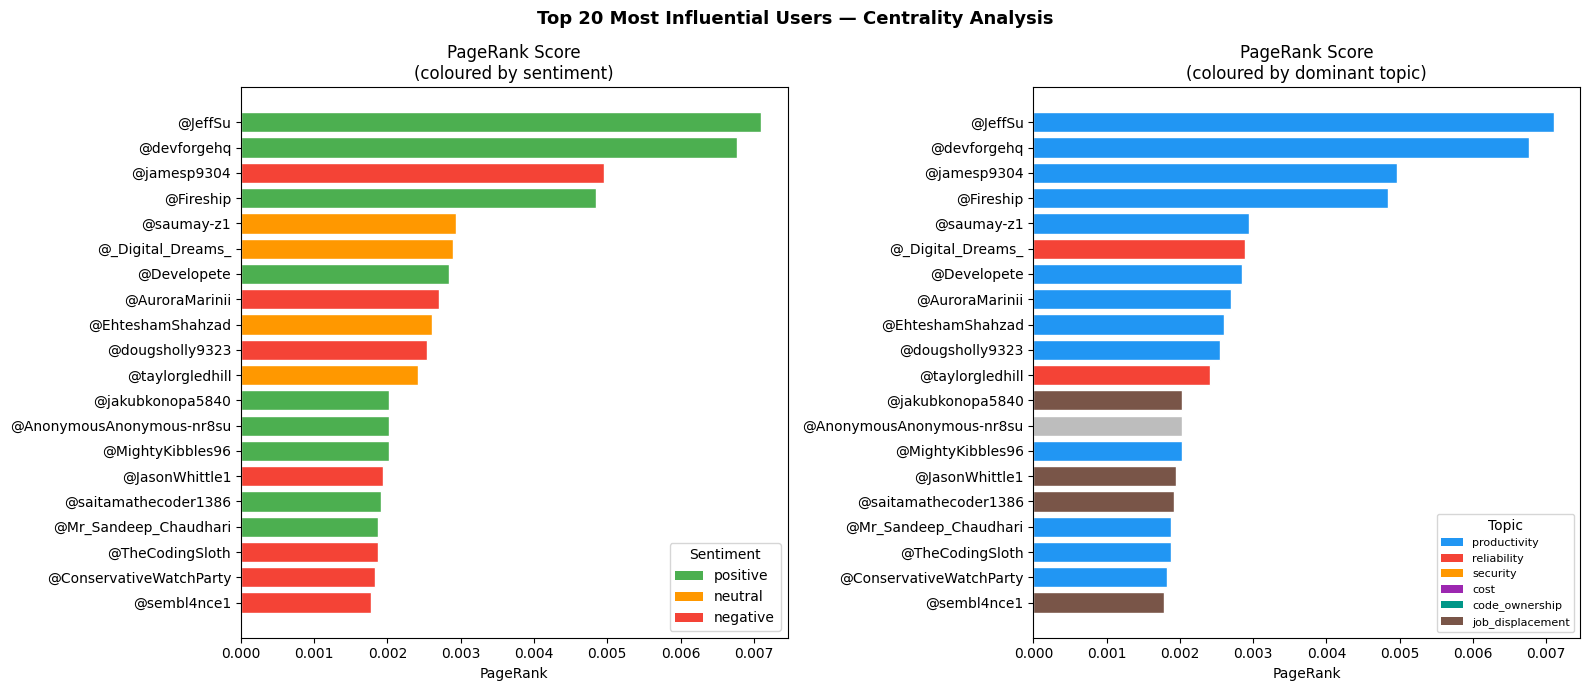

Saved top_users_centrality.png


In [15]:
SENTIMENT_COLORS = {"positive": "#4CAF50", "neutral": "#FF9800", "negative": "#F44336", "unknown": "#9E9E9E"}
TOPIC_COLORS = {
    "productivity": "#2196F3", "reliability": "#F44336",
    "security": "#FF9800", "cost": "#9C27B0",
    "code_ownership": "#009688", "job_displacement": "#795548",
    "other": "#9E9E9E", "unknown": "#BDBDBD"
}

top20 = centrality_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top 20 Most Influential Users — Centrality Analysis", fontsize=13, fontweight="bold")

# Plot 1 — PageRank coloured by sentiment
bar_colors = [SENTIMENT_COLORS.get(s, "#9E9E9E") for s in top20["sentiment_label"]]
axes[0].barh(top20["user"].str[:30][::-1], top20["pagerank"][::-1],
             color=bar_colors[::-1], edgecolor="white")
axes[0].set_title("PageRank Score\n(coloured by sentiment)")
axes[0].set_xlabel("PageRank")
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in SENTIMENT_COLORS.items() if k != "unknown"]
axes[0].legend(handles=legend_elements, title="Sentiment", loc="lower right")

# Plot 2 — PageRank coloured by topic
bar_colors2 = [TOPIC_COLORS.get(t, "#9E9E9E") for t in top20["dominant_topic"]]
axes[1].barh(top20["user"].str[:30][::-1], top20["pagerank"][::-1],
             color=bar_colors2[::-1], edgecolor="white")
axes[1].set_title("PageRank Score\n(coloured by dominant topic)")
axes[1].set_xlabel("PageRank")
legend_elements2 = [Patch(facecolor=v, label=k) for k, v in TOPIC_COLORS.items() if k not in ["other", "unknown"]]
axes[1].legend(handles=legend_elements2, title="Topic", loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_users_centrality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved top_users_centrality.png")

## 7. Community Detection (Louvain)

The Louvain algorithm detects communities by maximising modularity — grouping users who interact more with each other than with the rest of the network.

Louvain is chosen over alternatives (e.g. Girvan-Newman) because it scales well to networks of this size and consistently produces high-modularity partitions.

After detection, each community is characterised by its dominant sentiment and topic — revealing whether communities cluster around trust or distrust, and which concern themes define each group.

In [16]:
# Louvain runs on undirected graph
G_undirected_weighted = G.to_undirected()

log.info("Running Louvain community detection...")
partition = community_louvain.best_partition(G_undirected_weighted, weight="weight", random_state=42)

# Attach community labels to nodes
nx.set_node_attributes(G, partition, "community")

num_communities = len(set(partition.values()))
print(f"Communities detected: {num_communities}")
print(f"Modularity: {community_louvain.modularity(partition, G_undirected_weighted):.4f}")
print()

# Build community profiles
community_data = []
for comm_id in sorted(set(partition.values())):
    members = [u for u, c in partition.items() if c == comm_id]
    sentiments = [G.nodes[u].get("sentiment_label", "unknown") for u in members]
    topics = [G.nodes[u].get("dominant_topic", "unknown") for u in members]
    avg_sent = np.mean([G.nodes[u].get("avg_sentiment", 0) for u in members])

    dominant_sentiment = Counter(sentiments).most_common(1)[0][0]
    dominant_topic = Counter(topics).most_common(1)[0][0]

    community_data.append({
        "community_id": comm_id,
        "size": len(members),
        "dominant_sentiment": dominant_sentiment,
        "dominant_topic": dominant_topic,
        "avg_sentiment_score": round(avg_sent, 4),
        "positive_pct": round(sentiments.count("positive") / len(sentiments) * 100, 1),
        "negative_pct": round(sentiments.count("negative") / len(sentiments) * 100, 1),
    })

community_df = pd.DataFrame(community_data).sort_values("size", ascending=False)
community_df.to_csv(OUTPUT_DIR / "community_profiles.csv", index=False)

print("Community profiles (top 10 by size):")
print(community_df.head(10).to_string(index=False))

18:17:52 [INFO] Running Louvain community detection...


Communities detected: 979
Modularity: 0.9847

Community profiles (top 10 by size):
 community_id  size dominant_sentiment dominant_topic  avg_sentiment_score  positive_pct  negative_pct
           61   204           positive   productivity               0.4933          76.5           5.4
          129   181           positive   productivity               0.4456          76.8           7.7
            2    97           positive   productivity               0.1545          47.4          18.6
           78    94           positive   productivity               0.0885          45.7          23.4
          195    87           positive   productivity               0.2840          66.7          11.5
           45    86           positive   productivity               0.1839          54.7          18.6
           54    86           positive   productivity               0.1567          48.8          18.6
           30    82           positive   productivity               0.3123          62.2     

### Community Visualisations

18:17:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:17:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:17:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:17:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
18:17:55 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropria

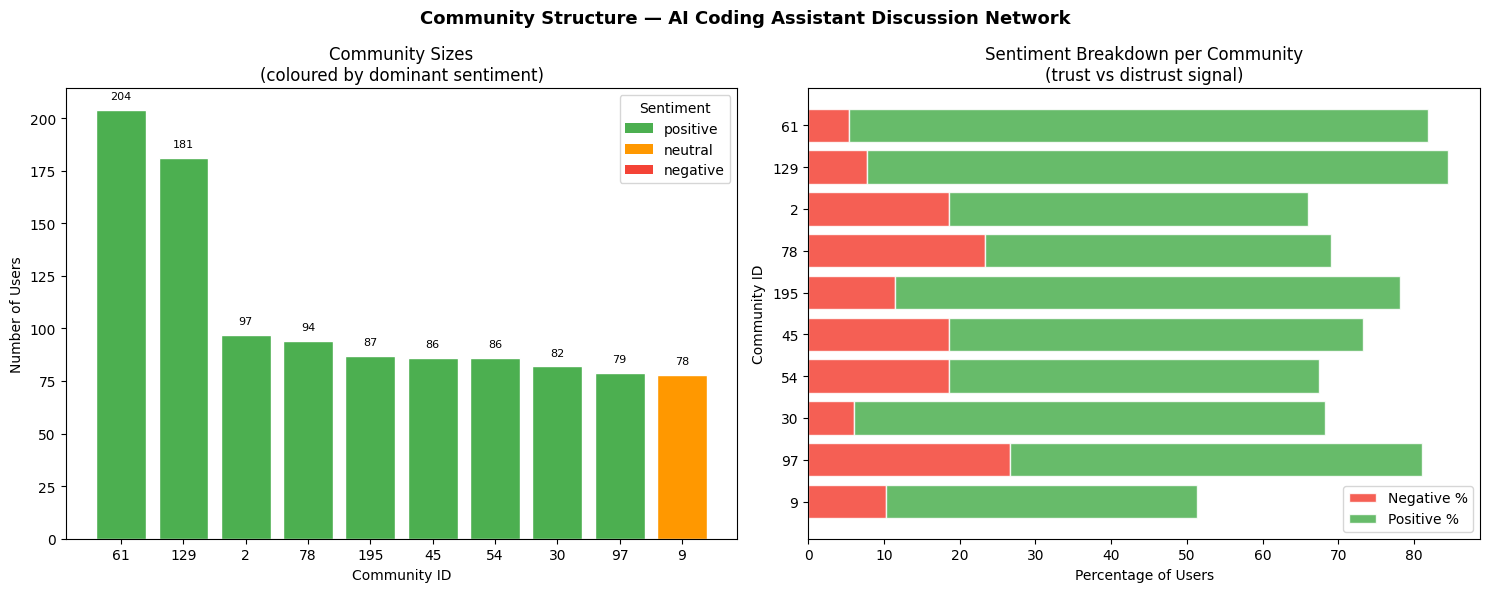

Saved community_profiles.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Community Structure — AI Coding Assistant Discussion Network", fontsize=13, fontweight="bold")

top_communities = community_df.head(10)

# Plot 1 — Community sizes coloured by dominant sentiment
bar_colors = [SENTIMENT_COLORS.get(s, "#9E9E9E") for s in top_communities["dominant_sentiment"]]
axes[0].bar(top_communities["community_id"].astype(str),
            top_communities["size"],
            color=bar_colors, edgecolor="white")
axes[0].set_title("Community Sizes\n(coloured by dominant sentiment)")
axes[0].set_xlabel("Community ID")
axes[0].set_ylabel("Number of Users")
legend_elements = [Patch(facecolor=v, label=k) for k, v in SENTIMENT_COLORS.items() if k != "unknown"]
axes[0].legend(handles=legend_elements, title="Sentiment")
for i, row in enumerate(top_communities.itertuples()):
    axes[0].text(i, row.size + 5, str(row.size), ha="center", fontsize=8)

# Plot 2 — Negative % per community (distrust signal)
axes[1].barh(top_communities["community_id"].astype(str)[::-1],
             top_communities["negative_pct"][::-1],
             color="#F44336", edgecolor="white", alpha=0.85, label="Negative %")
axes[1].barh(top_communities["community_id"].astype(str)[::-1],
             top_communities["positive_pct"][::-1],
             color="#4CAF50", edgecolor="white", alpha=0.85,
             left=top_communities["negative_pct"][::-1], label="Positive %")
axes[1].set_title("Sentiment Breakdown per Community\n(trust vs distrust signal)")
axes[1].set_xlabel("Percentage of Users")
axes[1].set_ylabel("Community ID")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "community_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved community_profiles.png")

## 8. Network Visualisation

A subgraph of the most connected users is visualised. The full graph is too large to display meaningfully, so we focus on the top 150 users by PageRank — the influential core of the network.

Node colour represents community membership. Node size represents PageRank score. Edge thickness represents interaction weight.

/var/folders/ky/frwppj2d4wq6ld_d8gktf7x40000gn/T/ipykernel_72543/1962613948.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_communities))


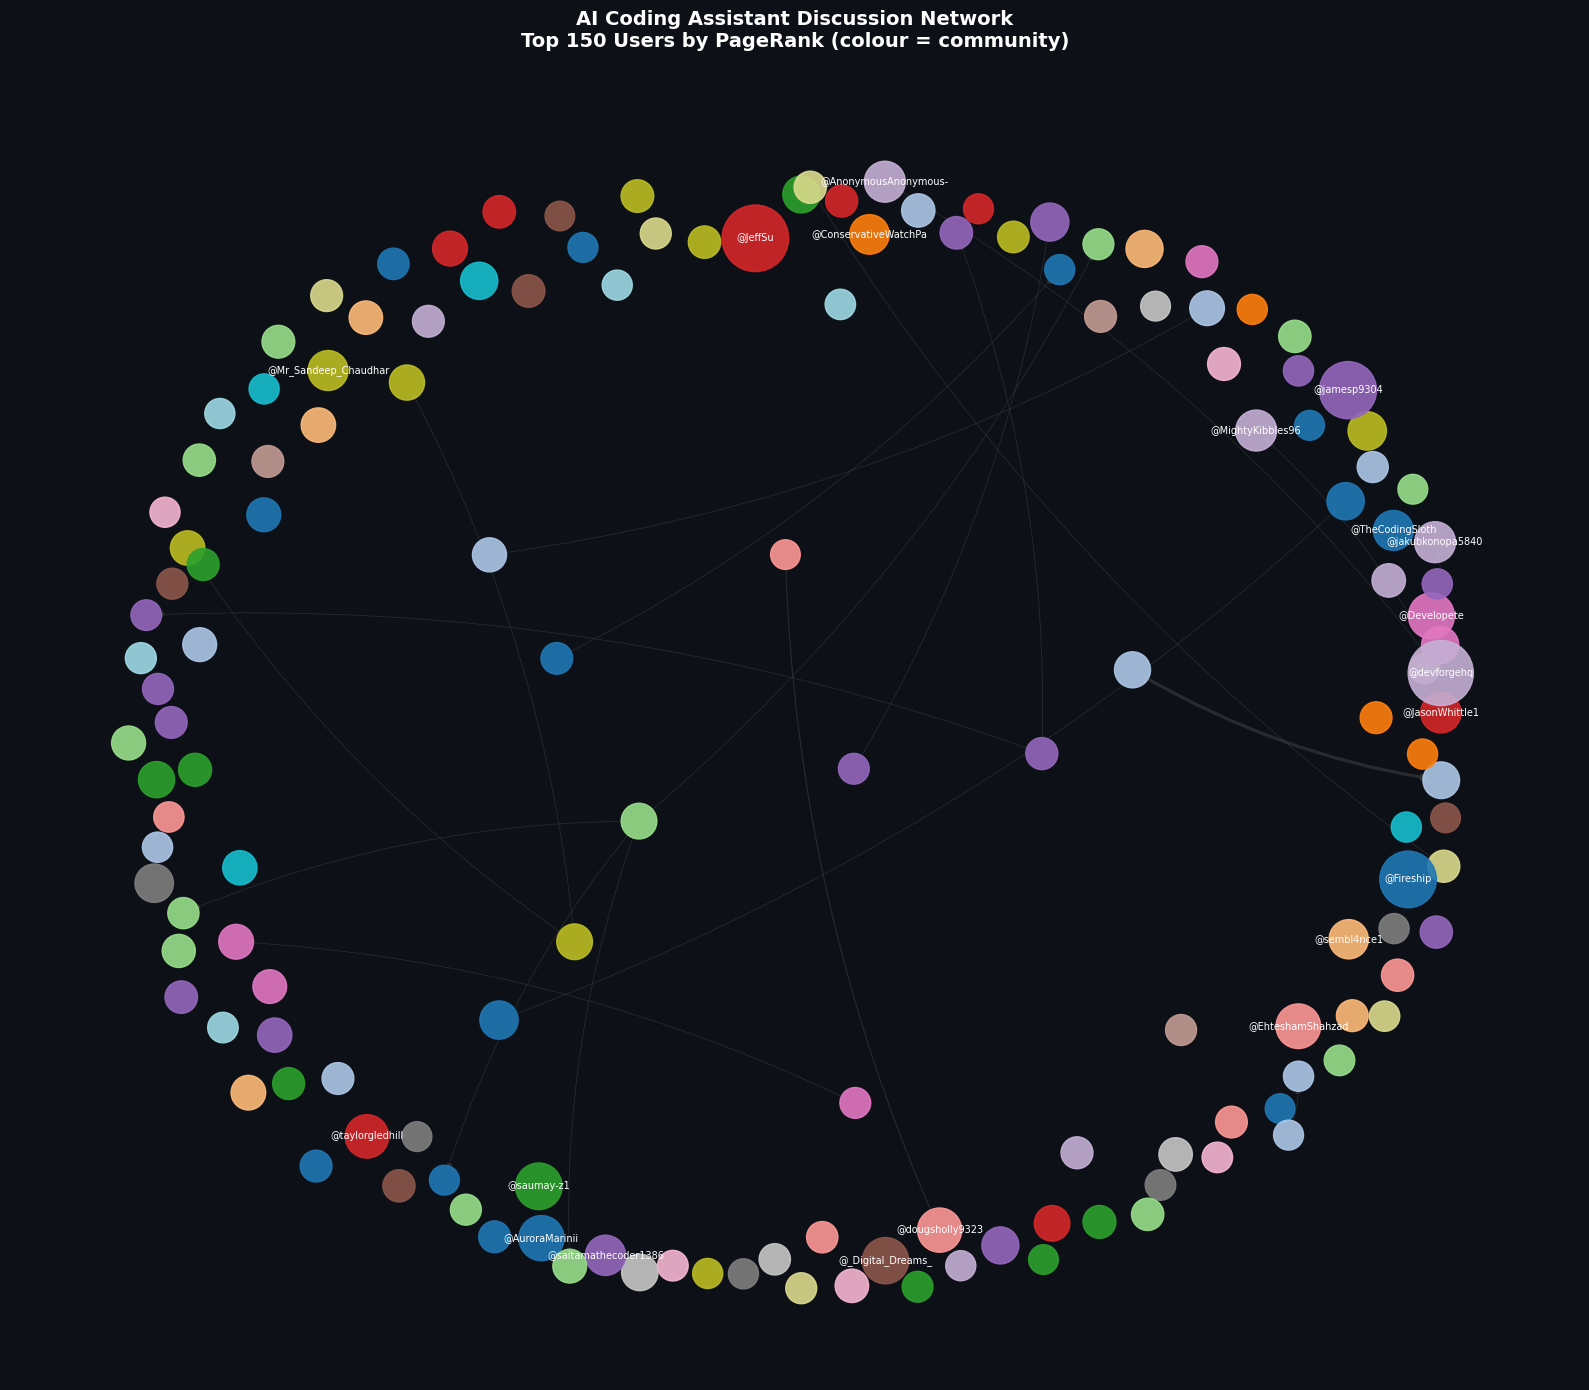

Saved network_graph.png


In [18]:
# Extract top 150 users by PageRank for visualisation
top_nodes = centrality_df.head(150)["user"].tolist()
G_sub = G.subgraph(top_nodes).copy()

# Assign colours by community
unique_communities = list(set(partition.get(n, -1) for n in G_sub.nodes()))
cmap = plt.cm.get_cmap("tab20", len(unique_communities))
comm_color_map = {c: mcolors.to_hex(cmap(i)) for i, c in enumerate(unique_communities)}
node_colors = [comm_color_map.get(partition.get(n, -1), "#9E9E9E") for n in G_sub.nodes()]

# Node sizes by PageRank
pr_vals = [pagerank.get(n, 0) for n in G_sub.nodes()]
max_pr = max(pr_vals) if pr_vals else 1
node_sizes = [300 + (v / max_pr) * 2000 for v in pr_vals]

# Edge weights
edge_weights = [G_sub[u][v].get("weight", 1) for u, v in G_sub.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [0.3 + (w / max_w) * 2 for w in edge_weights]

fig, ax = plt.subplots(figsize=(16, 14))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

pos = nx.spring_layout(G_sub, k=0.8, seed=42, iterations=50)

nx.draw_networkx_edges(
    G_sub, pos, ax=ax,
    edge_color="#444444",
    width=edge_widths,
    alpha=0.5,
    arrows=True,
    arrowsize=8,
    connectionstyle="arc3,rad=0.1"
)

nx.draw_networkx_nodes(
    G_sub, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9
)

# Label only top 20 nodes
top20_nodes = {n: n[:20] for n in centrality_df.head(20)["user"].tolist() if n in G_sub.nodes()}
nx.draw_networkx_labels(
    G_sub, pos, labels=top20_nodes, ax=ax,
    font_size=7, font_color="white"
)

ax.set_title("AI Coding Assistant Discussion Network\nTop 150 Users by PageRank (colour = community)",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "network_graph.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved network_graph.png")

## 9. Synthesis — Network Position × Sentiment × Topic

This is the core analytical contribution of the network stage — directly answering the research question:
*How do influential users and discussion communities shape concerns around trust and distrust in AI coding assistants?*

We examine:
1. Whether high-PageRank users lean positive or negative
2. Which topics are most discussed by influential users
3. Whether distrust-oriented communities have higher centrality than trust-oriented ones

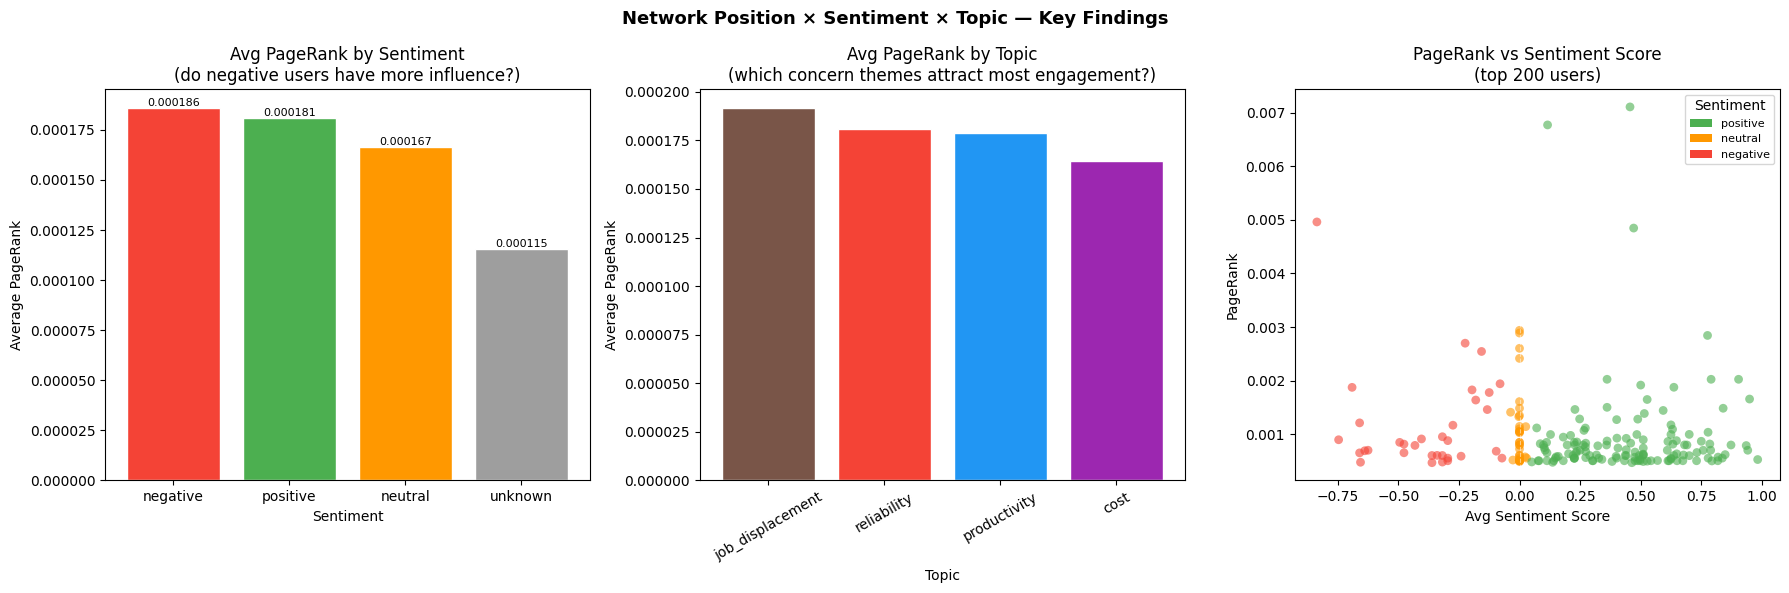

Saved synthesis_network_nlp.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Network Position × Sentiment × Topic — Key Findings", fontsize=13, fontweight="bold")

# Plot 1 — Avg PageRank by sentiment label
pr_by_sentiment = centrality_df.groupby("sentiment_label")["pagerank"].mean().sort_values(ascending=False)
bar_colors = [SENTIMENT_COLORS.get(s, "#9E9E9E") for s in pr_by_sentiment.index]
axes[0].bar(pr_by_sentiment.index, pr_by_sentiment.values, color=bar_colors, edgecolor="white")
axes[0].set_title("Avg PageRank by Sentiment\n(do negative users have more influence?)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Average PageRank")
for i, v in enumerate(pr_by_sentiment.values):
    axes[0].text(i, v + 0.000001, f"{v:.6f}", ha="center", fontsize=8)

# Plot 2 — Avg PageRank by dominant topic
pr_by_topic = centrality_df.groupby("dominant_topic")["pagerank"].mean().sort_values(ascending=False)
pr_by_topic = pr_by_topic[pr_by_topic.index != "unknown"]
bar_colors2 = [TOPIC_COLORS.get(t, "#9E9E9E") for t in pr_by_topic.index]
axes[1].bar(pr_by_topic.index, pr_by_topic.values, color=bar_colors2, edgecolor="white")
axes[1].set_title("Avg PageRank by Topic\n(which concern themes attract most engagement?)")
axes[1].set_xlabel("Topic")
axes[1].set_ylabel("Average PageRank")
axes[1].tick_params(axis="x", rotation=30)

# Plot 3 — Scatter: PageRank vs avg sentiment score
plot_df = centrality_df[centrality_df["sentiment_label"] != "unknown"].head(200)
scatter_colors = [SENTIMENT_COLORS.get(s, "#9E9E9E") for s in plot_df["sentiment_label"]]
axes[2].scatter(plot_df["avg_sentiment"], plot_df["pagerank"],
                c=scatter_colors, alpha=0.6, s=40, edgecolors="none")
axes[2].axvline(x=0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
axes[2].set_title("PageRank vs Sentiment Score\n(top 200 users)")
axes[2].set_xlabel("Avg Sentiment Score")
axes[2].set_ylabel("PageRank")
legend_elements = [Patch(facecolor=v, label=k) for k, v in SENTIMENT_COLORS.items() if k != "unknown"]
axes[2].legend(handles=legend_elements, title="Sentiment", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "synthesis_network_nlp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved synthesis_network_nlp.png")

## 10. Summary

In [20]:
print("=" * 55)
print("Network Analysis Complete")
print("=" * 55)
print(f"  Nodes (users):              {G.number_of_nodes():,}")
print(f"  Edges (reply interactions): {G.number_of_edges():,}")
print(f"  Graph density:              {nx.density(G):.6f}")
print(f"  Connected components:       {len(components):,}")
print(f"  Largest component:          {len(largest_cc):,} nodes")
print(f"  Communities detected:       {num_communities}")
print(f"  Modularity:                 {community_louvain.modularity(partition, G_undirected_weighted):.4f}")
print()
print("  Top 5 influential users (PageRank):")
for _, row in centrality_df.head(5).iterrows():
    print(f"    {row['user'][:35]:35s} PR: {row['pagerank']:.6f} | {row['sentiment_label']} | {row['dominant_topic']}")
print("=" * 55)
print()
print("Outputs saved to data/processed/network/:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f"  {f.name}")

Network Analysis Complete
  Nodes (users):              5,624
  Edges (reply interactions): 4,745
  Graph density:              0.000150
  Connected components:       959
  Largest component:          1,230 nodes
  Communities detected:       979
  Modularity:                 0.9847

  Top 5 influential users (PageRank):
    @JeffSu                             PR: 0.007105 | positive | productivity
    @devforgehq                         PR: 0.006769 | positive | productivity
    @jamesp9304                         PR: 0.004960 | negative | productivity
    @Fireship                           PR: 0.004846 | positive | productivity
    @saumay-z1                          PR: 0.002938 | neutral | productivity

Outputs saved to data/processed/network/:
  centrality_scores.csv
  community_profiles.csv
  community_profiles.png
  degree_distribution.png
  network_graph.png
  synthesis_network_nlp.png
  top_users_centrality.png


## 11. Outputs

All outputs saved to `data/processed/network/`:

| File | Description |
|---|---|
| `centrality_scores.csv` | PageRank, in-degree, betweenness per user with sentiment + topic labels |
| `community_profiles.csv` | Size, dominant sentiment, dominant topic per community |
| `degree_distribution.png` | In/out degree distribution charts |
| `top_users_centrality.png` | Top 20 users by PageRank coloured by sentiment and topic |
| `community_profiles.png` | Community sizes and sentiment breakdown |
| `network_graph.png` | Network visualisation — top 150 users, coloured by community |
| `synthesis_network_nlp.png` | PageRank vs sentiment/topic cross-analysis |

### Adding HN and GitHub data
When your teammates have collected their data, ensure their edge files follow this format:
```json
[
  {"source": "user_a", "target": "user_b", "weight": 1},
  ...
]
```
Save them to:
- `data/processed/hackernews/hn_reply_edges.json`
- `data/processed/github/gh_reply_edges.json`

Then rerun this notebook from cell 1 — the loader in section 2 will automatically pick them up.